# SUSHI TUTORIAL 2026

In [1]:
%load_ext autoreload  
%autoreload 2
import sys, os
sys.path.insert(0,'code/')

import torch
import numpy as np
import pickle
import warnings
from matplotlib import pyplot as plt
from matplotlib import cm as cm
from sklearn.model_selection import train_test_split
from astropy.io import fits

from training_PCA_NN_torch import load_model_for_sushi, untransform_physpar
from SUSHI_PCANN_linked_params_torch import SUSHI

# ── Device selection ─────────────────────────────────────────────────────────
device = torch.device("mps" if torch.backends.mps.is_available()
                      else "cpu")
print(f"PyTorch SUSHI running on: {device}")

PyTorch SUSHI running on: mps


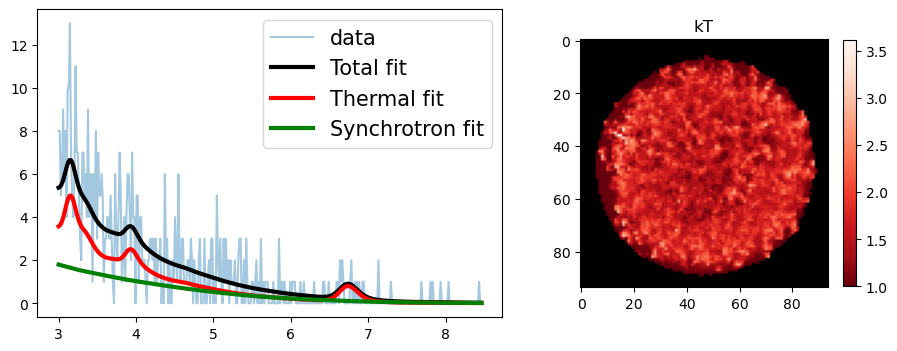

In [2]:
# =============================================================================
# Loading the toymodel
# =============================================================================
with open("data/toymodel_data.p", "rb") as f:
    DATA = pickle.load(f)
with open("data/toymodel_ground_truth.p", "rb") as f:
    GT = pickle.load(f)


def show_data_cube(i, j, param):
    E = GT["channels"]
    fig, ax = plt.subplots(1, 2, figsize=(11, 4),
                           gridspec_kw={'width_ratios': [3, 2]})
    ax[0].plot(E, DATA[:, i, j], alpha=0.4, label="data")
    ax[0].plot(E, GT["Total"][:, i, j], "k", lw=3, label="Total fit")
    ax[0].plot(E, GT["Thermal"][:, i, j], "r", lw=3, label="Thermal fit")
    ax[0].plot(E, GT["Synch"][:, i, j], "g", lw=3, label="Synchrotron fit")
    cmap = cm.Reds_r
    cmap.set_bad('black', 1.)
    pcm = ax[1].imshow(GT["Params"][param], cmap=cmap)
    ax[0].legend(loc="upper right", fontsize=15)
    ax[1].set_title(param)
    fig.colorbar(pcm, ax=ax[1], shrink=0.8)

show_data_cube(40, 35, param="kT")
plt.show()

In [4]:
# =============================================================================
# Loading the surrogate models (differentiable — for SUSHI autograd)
# =============================================================================
f_name_synch    = "models/PCA_NN_Synch_Chandra_batches_10000_seed_42_torch.p"
f_name_thermal  = f"models/PCA_NN_Chandra_TychoARF_batches_{int(10e4)}_seed_42_torch.p"

# load_model_for_sushi returns a FULLY DIFFERENTIABLE callable 
# (params -> physical spectra) that works inside SUSHI's autograd gradient loop.
Synch_model,   synch_params_cnst, synch_spec_cnst  = load_model_for_sushi(f_name_synch,   device=device)
Thermal_model, therm_params_cnst, therm_spec_cnst  = load_model_for_sushi(f_name_thermal, device=device)

# Model dictionaries passed to SUSHI
# "model" : callable(Theta: torch.Tensor) -> spectra: torch.Tensor
apec_dir  = {"model": Thermal_model,
             "param_names": ["kT", "z"],
             "first_param": [0, 0.16],
             "params_cnst": therm_params_cnst}

synch_dir = {"model": Synch_model,
             "param_names": ["pho"],
             "first_param": [0.5],
             "params_cnst": synch_params_cnst}

In [5]:
# =============================================================================
# Run SUSHI
# =============================================================================
res_notlinked = SUSHI(DATA, apec_dir, synch_dir,
                      component_names=["Thermal", "Synchrotron"],
                      niter=1000, stop=np.nan,
                      J=2, kmad=1, alpha_A=1, alpha_T=1e-5,
                      background=None,
                      Cost_function="Poisson",
                      file_name="SUSHI_results_thermal_synch_torch",
                      intermediate_save=False, save=500, restart=None,
                      device=device)

SUSHI running on device: mps
Shape of the data: 375 channels, 94x94 pixels.
Models:
Thermal
Synchrotron
Number of components: 2


Loss=-2.9580e+06, Mean diff=5.99e-04: 100%|██████████| 1000/1000 [01:22<00:00, 12.05it/s]


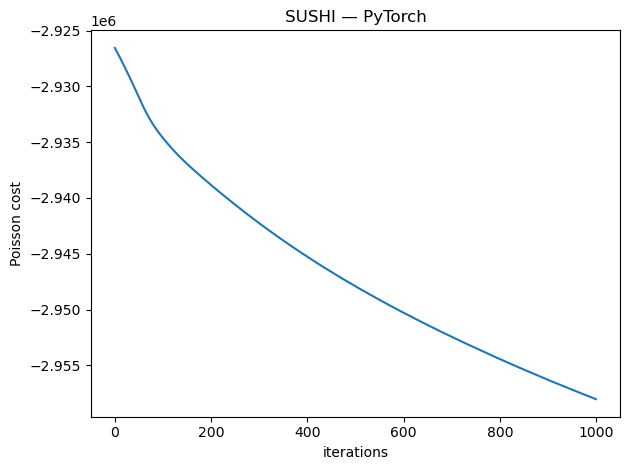

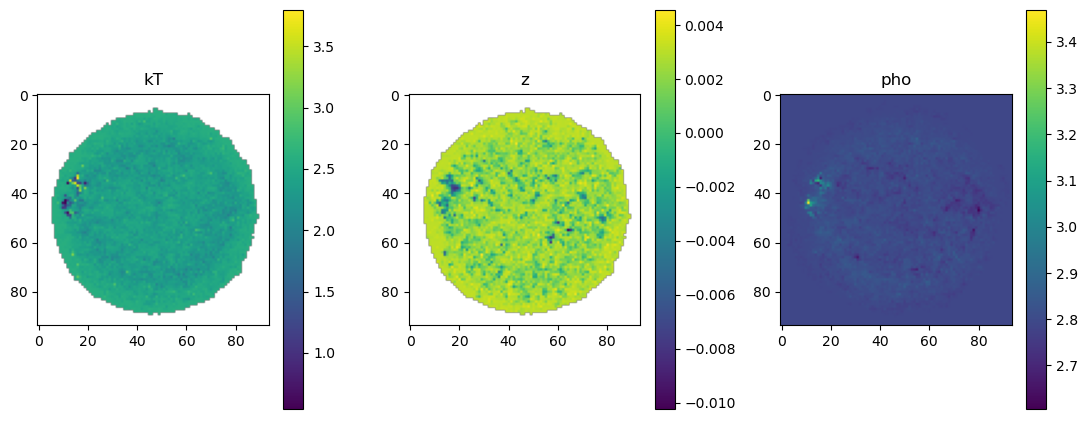

In [6]:
# =============================================================================
# Results
# =============================================================================
plt.figure()
plt.plot(res_notlinked["Likelihood"])
plt.xlabel("iterations")
plt.ylabel("Poisson cost")
plt.title("SUSHI — PyTorch")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 3, figsize=(11, 6))
Mask = 1 - np.isnan(GT['Params']['kT']).astype(float)
Mask[np.where(np.isnan(GT['Params']['kT']))] = np.nan

pcm = ax[0].imshow(Mask * res_notlinked["Theta"][0][:, :, 0])
ax[0].set_title("kT")
fig.colorbar(pcm, ax=ax[0], shrink=0.7)

pcm = ax[1].imshow(Mask * res_notlinked["Theta"][0][:, :, 1])
ax[1].set_title("z")
fig.colorbar(pcm, ax=ax[1], shrink=0.7)

pcm = ax[2].imshow(res_notlinked["Theta"][1][:, :, 0])
ax[2].set_title("pho")
fig.colorbar(pcm, ax=ax[2], shrink=0.7)

plt.tight_layout()
plt.show()

### Training the surrogate models 
This notebook assumes that the surrogate models have been trained. A tutorial on how to train the "PCA-NN" model is provided in the notebook Surrogate_Model_Training.ipynb. 

### What should my models be like? 
The surrogate models used to be SUSHI should be already convolved with instrumental response (RMF, ARF) as appropriately chosen for the data-set. This should be done when generating the training/testing sets. The trained models will take as input standardized variables, and return the spectra projected on the PCA-defined subspace. Thus, SUSHI's output will need to be transformed back to physical units. 

### What about linked parameters?
In the case where a parameter should not vary from one model to the next (for example, a $n_H$ parameter that should be the same in a thermal and synchrotron model), SUSHI will deal with that, but the **unit change of the parameter should be the same**! The way to ensure this is also detailed in Surrogate_Model_Training.ipynb. 

# Without linked parameters 

## Loading the toymodel

In [2]:
with open("data/toymodel_data.p","rb") as f:
    DATA=pickle.load(f)
with open("data/toymodel_ground_truth.p","rb") as f:
    GT=pickle.load(f)

In [3]:
def show_data_cube(i,j,param):
    #i,j: pixel position
    #param: parameter to show the ground truth of. 
    #    kT: temperature. z: velocity redshift. 
    #    pho: photon index (synchrotron component)
    E=GT["channels"]
    fig,ax=plt.subplots(1,2,figsize=(11,4),gridspec_kw={'width_ratios': [3, 2]})
    ax[0].plot(E,DATA[:,i,j],alpha=0.4,label="data")
    ax[0].plot(E,GT["Total"][:,i,j],"k",lw=3,label="Total fit")
    ax[0].plot(E,GT["Thermal"][:,i,j],"r",lw=3,label="Thermal fit")
    ax[0].plot(E,GT["Synch"][:,i,j],"g",lw=3,label="Synchrotron fit")
    cmap = cm.Reds_r
    cmap.set_bad('black',1.)
    pcm=ax[1].imshow(GT["Params"][param],cmap=cmap)
    ax[0].legend(loc="upper right",fontsize=15)
    #ax[0].set_title(f"pixel ({i},{j})")
    #ax[1].scatter(j,i,c="r",marker="+")
    ax[1].set_title(param)
    fig.colorbar(pcm,ax=ax[1],shrink=0.8)
    #fig.suptitle("Toy Model")
interact(show_data_cube,i=(0,93,1),j=(0,93,1),param=["kT","z","pho"])


interactive(children=(IntSlider(value=46, description='i', max=93), IntSlider(value=46, description='j', max=9…

<function __main__.show_data_cube(i, j, param)>

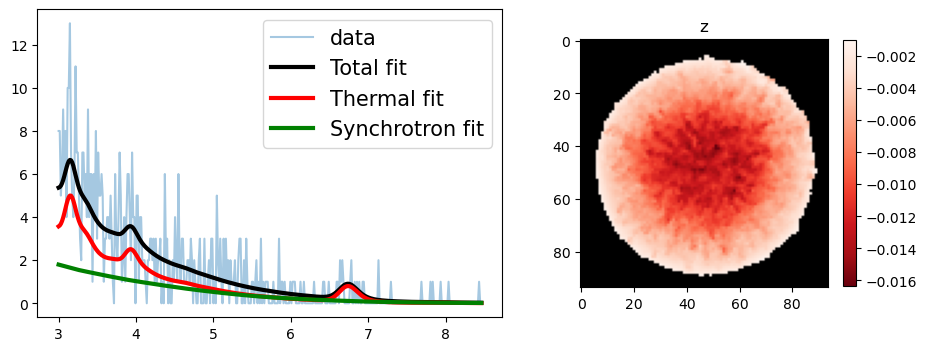

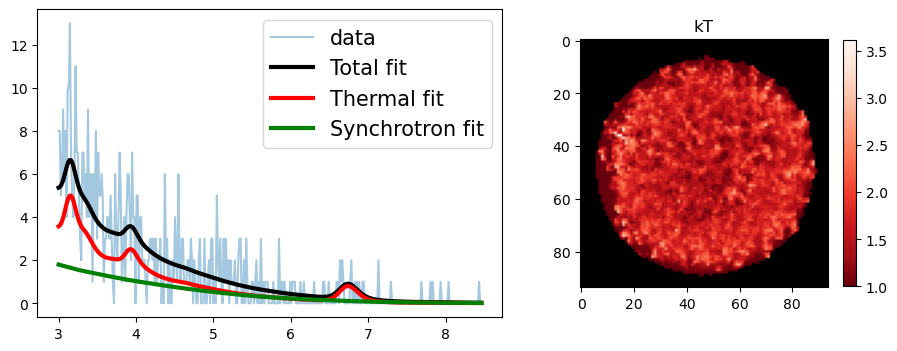

In [4]:
show_data_cube(40,35,param="z")
show_data_cube(40,35,param="kT")

# Loading the models

In [5]:
#SPECTRAL MODELS 
f_name_synch=f"models/PCA_NN_Synch_Chandra_batches_1000_seed_42.p"
NN_Synch,NN_fromphys_Synch,synch_params_cnst,synch_spec_cnst=load_model(f_name_synch)

f_name_thermal=f"models/PCA_NN_Chandra_TychoARF_batches_{int(5e4)}_seed_{42}.p"
NN_Thermal,NN_fromphys_Thermal,therm_params_cnst,therm_spec_cnst=load_model(f_name_thermal)

def Synch_trans_to_phys(trans_param):
    return untransform_spec(NN_Synch(trans_param),synch_spec_cnst)
def Thermal_trans_to_phys(trans_param):
    return untransform_spec(NN_Thermal(trans_param),therm_spec_cnst)
    
apec_dir={"model":Thermal_trans_to_phys,"param_names":["kT","z"],
           "first_param":[0,0.16],"params_cnst":therm_params_cnst}
synch_dir={"model":Synch_trans_to_phys,"param_names":["pho"],
           "first_param":[0.5],"params_cnst":synch_params_cnst}

## SUSHI

In [ ]:
res_notlinked=SUSHI(DATA,apec_dir,synch_dir,component_names=["Thermal","Synchrotron"],
          niter=10000,stop=np.nan,J=2,kmad=1,alpha_A=1,alpha_T=1e-5,
          background=None,Cost_function="Poisson"
          ,file_name="SUSHI_results_thermal_synch",
          intermediate_save=False,save=500,restart=None)

Shape of the data: 375 channels, 94x94 pixels.
Models:
Thermal
Synchrotron
Number of components: 2


Loss:   0%|          | 0/10000 [00:00<?, ?it/s]

## Showing results

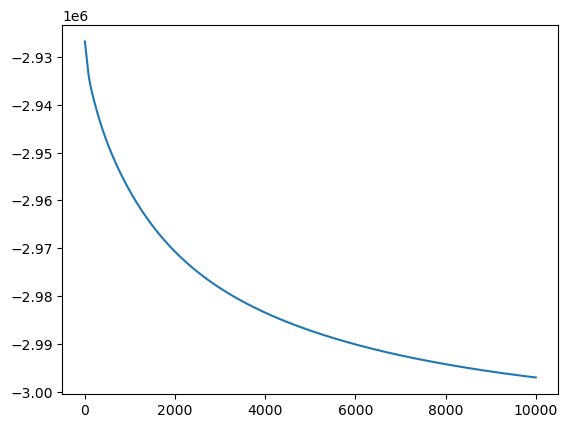

In [80]:
plt.plot(res_notlinked["Likelihood"])

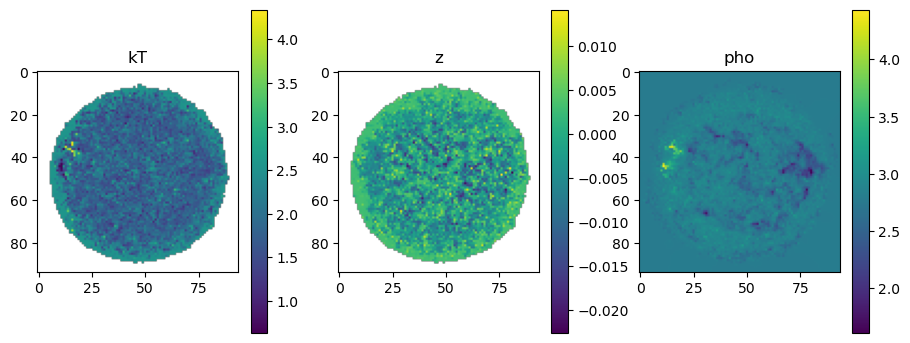

In [81]:
fig,ax=plt.subplots(1,3,figsize=(11,6))
Mask=1-np.isnan(GT['Params']['kT']).astype(float)
Mask[np.where(np.isnan(GT['Params']['kT']))]=np.nan

pcm=ax[0].imshow(Mask*res_notlinked["Theta"][0][:,:,0])
ax[0].set_title("kT")
fig.colorbar(pcm,ax=ax[0],shrink=0.7)

pcm=ax[1].imshow(Mask*res_notlinked["Theta"][0][:,:,1])
ax[1].set_title("z")
fig.colorbar(pcm,ax=ax[1],shrink=0.7)

pcm=ax[2].imshow(res_notlinked["Theta"][1][:,:,0])
ax[2].set_title("pho")
fig.colorbar(pcm,ax=ax[2],shrink=0.7)


# With linked parameters 

## Loading the toymodel

In [2]:
with open("cubes_linked_params.p","rb") as f:
    cubes_linked_params=pickle.load(f)
nH=0.6
abund=5
M,N=94,94
L=580-205
imin=205 #3 keV
imax=580 #8.48 keV
cube_blue=cubes_linked_params["blue"]["spectra"]
cube_red=cubes_linked_params["red"]["spectra"]
z_map_simu=cubes_linked_params["blue"]["z"]
kT_map_simu=cubes_linked_params["blue"]["kT"]
E=cubes_linked_params["Energy"]
def show_cubes(i,j,k):
    fig,ax=plt.subplots(2,2,figsize=(11,8))
    ax[0,0].imshow(cube_red[k,:,:])
    ax[0,1].plot(cube_red[:,i,j])
    ax[0,1].set_title(f"kT={kT_map_simu[i,j]:.2f} keV, z={-1*z_map_simu[i,j]:.4f}" )
    ax[1,0].imshow(cube_blue[k,:,:])
    ax[1,1].plot(cube_blue[:,i,j])
    ax[1,1].set_title(f"kT={kT_map_simu[i,j]:.2f} keV, z={z_map_simu[i,j]:.4f}" )
    plt.show()
interact(show_cubes,i=(0,M-1,1),j=(0,M-1,1),k=(0,L-1,1))

interactive(children=(IntSlider(value=46, description='i', max=93), IntSlider(value=46, description='j', max=9…

<function __main__.show_cubes(i, j, k)>

In [3]:
Noisy_Data=np.random.poisson((cube_red+cube_blue)*5e1)
GT={"Total":(cube_red+cube_blue)*5e1,
    "Thermal_1":cube_red*5e1,
    "Thermal_2":cube_blue*5e1
   }
Params={"Thermal_1":{"kT":kT_map_simu,"z_1":-1*z_map_simu},
        "Thermal_2":{"kT":kT_map_simu,"z_2":z_map_simu}
       }

## Loading the models

In [65]:
f_name_thermal=f"PCA_NN_Chandra_TychoARF_batches_{int(5e4)}_seed_{42}.p"
NN_Thermal_Chandra,NN_fromphys_Thermal_Chandra,params_cnst,spec_cnst=load_model(f_name_thermal)

def Thermal_trans_to_phys(trans_param):
    return untransform_spec(NN_Thermal_Chandra(trans_param),spec_cnst)

apec_dir1={"model":Thermal_trans_to_phys,"param_names":["kT","z_1"],
           "first_param":[0,0.16],"params_cnst":params_cnst}
apec_dir2={"model":Thermal_trans_to_phys,"param_names":["kT","z_2"],
           "first_param":[1,-0.16],"params_cnst":params_cnst}

## The code

In [66]:
#Something unclear about the input or output? Check the docstring of the SUSHI function! 
#print(SUSHI.__doc__)

In [67]:
res_linked=SUSHI(Noisy_Data,apec_dir1,apec_dir2,component_names=["Thermal_1","Thermal_2"],
          niter=5000,stop=np.nan,J=2,kmad=1,
          background=np.zeros(L),Cost_function="Poisson"
          ,file_name="SUSHI_results_2apec_linked_kT",
          intermediate_save=False,save=500,restart=None)

Shape of the data: 375 channels, 94x94 pixels.
Models:
Thermal_1
Thermal_2
Number of components: 2
Parameter kT marked as linked.
Model Thermal_1 marked as parent model.
Parameter  kT in model Thermal_2  is linked to Parameter kT in model Thermal_1


Loss:   0%|          | 0/5000 [00:00<?, ?it/s]

## Showing results

Text(0, 0.5, 'likelihood')

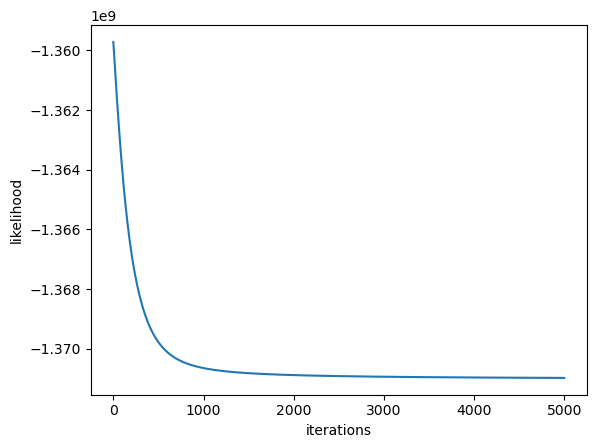

In [68]:
plt.plot(res_linked["Likelihood"])
plt.xlabel("iterations")
plt.ylabel("likelihood")

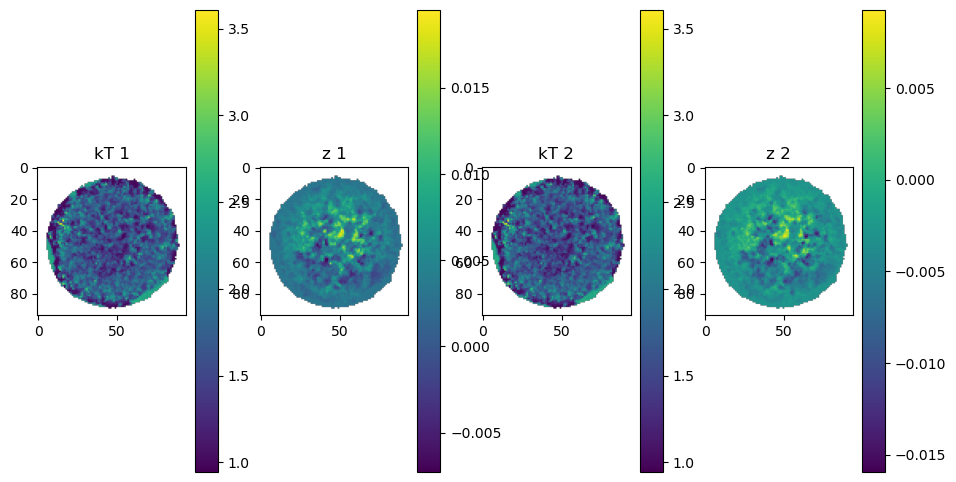

In [71]:
fig,ax=plt.subplots(1,4,figsize=(11,6))
Mask=1-np.isnan(GT['Params']['kT']).astype(float)
Mask[np.where(np.isnan(GT['Params']['kT']))]=np.nan

pcm=ax[0].imshow(Mask*res_linked["Theta"][0][:,:,0])
ax[0].set_title("kT 1")
fig.colorbar(pcm,ax=ax[0])

pcm=ax[1].imshow(Mask*res_linked["Theta"][0][:,:,1])
ax[1].set_title("z 1")
fig.colorbar(pcm,ax=ax[1])

pcm=ax[2].imshow(Mask*res_linked["Theta"][1][:,:,0])
ax[2].set_title("kT 2")
fig.colorbar(pcm,ax=ax[2])

pcm=ax[3].imshow(Mask*res_linked["Theta"][1][:,:,1])
ax[3].set_title("z 2")
fig.colorbar(pcm,ax=ax[3])
